In [1]:
%pip install qiskit qiskit-ibm-runtime
%pip install 'qiskit[visualization]'
%pip install qiskit-aer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.4/149.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.9/434.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
import math
from qiskit.visualization import plot_distribution, plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)


In [8]:
pi = math.pi
q = QuantumRegister(18,'q')
c = ClassicalRegister(2,'c')
qc = QuantumCircuit(q,c)

In [4]:
QiskitRuntimeService.save_account(channel="ibm_quantum", token="Your token here", overwrite=True, set_as_default=True)
service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy(min_num_qubits=127)

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
circuit_qc = pm.run(qc)
noise_model = NoiseModel.from_backend(backend)

Encoding

In [9]:
qc.cx(q[0], q[6])
qc.cx(q[1], q[7])
qc.cx(q[0], q[12])
qc.cx(q[1], q[13])
qc.h(q[0])
qc.h(q[1])
qc.h(q[6])
qc.h(q[7])
qc.h(q[12])
qc.h(q[13])
qc.cx(q[0], q[2])
qc.cx(q[1], q[3])
qc.cx(q[0], q[4])
qc.cx(q[1], q[5])
qc.cx(q[6], q[8])
qc.cx(q[7], q[9])
qc.cx(q[6], q[10])
qc.cx(q[7], q[11])
qc.cx(q[12], q[14])
qc.cx(q[13], q[15])
qc.cx(q[12], q[16])
qc.cx(q[13], q[17])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=18, num_clbits=0, params=[]), qubits=(<Qubit register=(18, "q"), index=0>, <Qubit register=(18, "q"), index=1>, <Qubit register=(18, "q"), index=2>, <Qubit register=(18, "q"), index=3>, <Qubit register=(18, "q"), index=4>, <Qubit register=(18, "q"), index=5>, <Qubit register=(18, "q"), index=6>, <Qubit register=(18, "q"), index=7>, <Qubit register=(18, "q"), index=8>, <Qubit register=(18, "q"), index=9>, <Qubit register=(18, "q"), index=10>, <Qubit register=(18, "q"), index=11>, <Qubit register=(18, "q"), index=12>, <Qubit register=(18, "q"), index=13>, <Qubit register=(18, "q"), index=14>, <Qubit register=(18, "q"), index=15>, <Qubit register=(18, "q"), index=16>, <Qubit register=(18, "q"), index=17>), clbits=())

Grover's Algorithm

In [10]:
qc.h(q[0])
qc.h(q[1])
qc.x(q[1])
qc.cz(q[0],q[1])
qc.x(q[1])
qc.h(q[0])
qc.h(q[1])
qc.x(q[0])
qc.x(q[1])
qc.h(q[1])
qc.cx(q[0],q[1])
qc.h(q[1])
qc.x(q[0])
qc.x(q[1])
qc.h(q[0])
qc.h(q[1])

qc.h(q[2])
qc.h(q[3])
qc.x(q[3])
qc.cz(q[2],q[3])
qc.x(q[3])
qc.h(q[2])
qc.h(q[3])
qc.x(q[2])
qc.x(q[3])
qc.h(q[3])
qc.cx(q[2],q[3])
qc.h(q[3])
qc.x(q[2])
qc.x(q[3])
qc.h(q[2])
qc.h(q[3])

qc.h(q[4])
qc.h(q[5])
qc.x(q[5])
qc.cz(q[4],q[5])
qc.x(q[5])
qc.h(q[4])
qc.h(q[5])
qc.x(q[4])
qc.x(q[5])
qc.h(q[5])
qc.cx(q[4],q[5])
qc.h(q[5])
qc.x(q[4])
qc.x(q[5])
qc.h(q[4])
qc.h(q[5])

qc.h(q[6])
qc.h(q[7])
qc.x(q[7])
qc.cz(q[6],q[7])
qc.x(q[7])
qc.h(q[6])
qc.h(q[7])
qc.x(q[6])
qc.x(q[7])
qc.h(q[7])
qc.cx(q[6],q[7])
qc.h(q[7])
qc.x(q[6])
qc.x(q[7])
qc.h(q[6])
qc.h(q[7])

qc.h(q[8])
qc.h(q[9])
qc.x(q[9])
qc.cz(q[8],q[9])
qc.x(q[9])
qc.h(q[8])
qc.h(q[9])
qc.x(q[8])
qc.x(q[9])
qc.h(q[9])
qc.cx(q[8],q[9])
qc.h(q[9])
qc.x(q[8])
qc.x(q[9])
qc.h(q[8])
qc.h(q[9])

qc.h(q[10])
qc.h(q[11])
qc.x(q[11])
qc.cz(q[10],q[11])
qc.x(q[11])
qc.h(q[10])
qc.h(q[11])
qc.x(q[10])
qc.x(q[11])
qc.h(q[11])
qc.cx(q[10],q[11])
qc.h(q[11])
qc.x(q[10])
qc.x(q[11])
qc.h(q[10])
qc.h(q[11])

qc.h(q[12])
qc.h(q[13])
qc.x(q[13])
qc.cz(q[12],q[13])
qc.x(q[13])
qc.h(q[12])
qc.h(q[13])
qc.x(q[12])
qc.x(q[13])
qc.h(q[13])
qc.cx(q[12],q[13])
qc.h(q[13])
qc.x(q[12])
qc.x(q[13])
qc.h(q[12])
qc.h(q[13])

qc.h(q[14])
qc.h(q[15])
qc.x(q[15])
qc.cz(q[14],q[15])
qc.x(q[15])
qc.h(q[14])
qc.h(q[15])
qc.x(q[14])
qc.x(q[15])
qc.h(q[15])
qc.cx(q[14],q[15])
qc.h(q[15])
qc.x(q[14])
qc.x(q[15])
qc.h(q[14])
qc.h(q[15])

qc.h(q[16])
qc.h(q[17])
qc.x(q[17])
qc.cz(q[16],q[17])
qc.x(q[17])
qc.h(q[16])
qc.h(q[17])
qc.x(q[16])
qc.x(q[17])
qc.h(q[17])
qc.cx(q[16],q[17])
qc.h(q[17])
qc.x(q[16])
qc.x(q[17])
qc.h(q[16])
qc.h(q[17])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=18, num_clbits=0, params=[]), qubits=(<Qubit register=(18, "q"), index=0>, <Qubit register=(18, "q"), index=1>, <Qubit register=(18, "q"), index=2>, <Qubit register=(18, "q"), index=3>, <Qubit register=(18, "q"), index=4>, <Qubit register=(18, "q"), index=5>, <Qubit register=(18, "q"), index=6>, <Qubit register=(18, "q"), index=7>, <Qubit register=(18, "q"), index=8>, <Qubit register=(18, "q"), index=9>, <Qubit register=(18, "q"), index=10>, <Qubit register=(18, "q"), index=11>, <Qubit register=(18, "q"), index=12>, <Qubit register=(18, "q"), index=13>, <Qubit register=(18, "q"), index=14>, <Qubit register=(18, "q"), index=15>, <Qubit register=(18, "q"), index=16>, <Qubit register=(18, "q"), index=17>), clbits=())

Decoding

In [11]:
qc.cx(q[0], q[2])
qc.cx(q[1], q[3])
qc.cx(q[0], q[4])
qc.cx(q[1], q[5])
qc.ccx(q[4], q[2], q[0])
qc.ccx(q[5], q[3], q[1])
qc.cx(q[6], q[8])
qc.cx(q[7], q[9])
qc.cx(q[6], q[10])
qc.cx(q[7], q[11])
qc.ccx(q[10], q[8], q[6])
qc.ccx(q[11], q[9], q[7])
qc.cx(q[12], q[14])
qc.cx(q[13], q[15])
qc.cx(q[12], q[16])
qc.cx(q[13], q[17])
qc.ccx(q[16], q[14], q[12])
qc.ccx(q[17], q[15], q[13])
qc.h(q[0])
qc.h(q[1])
qc.h(q[6])
qc.h(q[7])
qc.h(q[12])
qc.h(q[13])
qc.cx(q[0], q[6])
qc.cx(q[1], q[7])
qc.cx(q[0], q[12])
qc.cx(q[1], q[13])
qc.ccx(q[12], q[6], q[0])
qc.ccx(q[13], q[7], q[1])

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=18, num_clbits=0, params=[]), qubits=(<Qubit register=(18, "q"), index=0>, <Qubit register=(18, "q"), index=1>, <Qubit register=(18, "q"), index=2>, <Qubit register=(18, "q"), index=3>, <Qubit register=(18, "q"), index=4>, <Qubit register=(18, "q"), index=5>, <Qubit register=(18, "q"), index=6>, <Qubit register=(18, "q"), index=7>, <Qubit register=(18, "q"), index=8>, <Qubit register=(18, "q"), index=9>, <Qubit register=(18, "q"), index=10>, <Qubit register=(18, "q"), index=11>, <Qubit register=(18, "q"), index=12>, <Qubit register=(18, "q"), index=13>, <Qubit register=(18, "q"), index=14>, <Qubit register=(18, "q"), index=15>, <Qubit register=(18, "q"), index=16>, <Qubit register=(18, "q"), index=17>), clbits=())

Measure the logical qubits

In [12]:
qc.measure(q[0], 0)
qc.measure(q[1], 1)

Draw

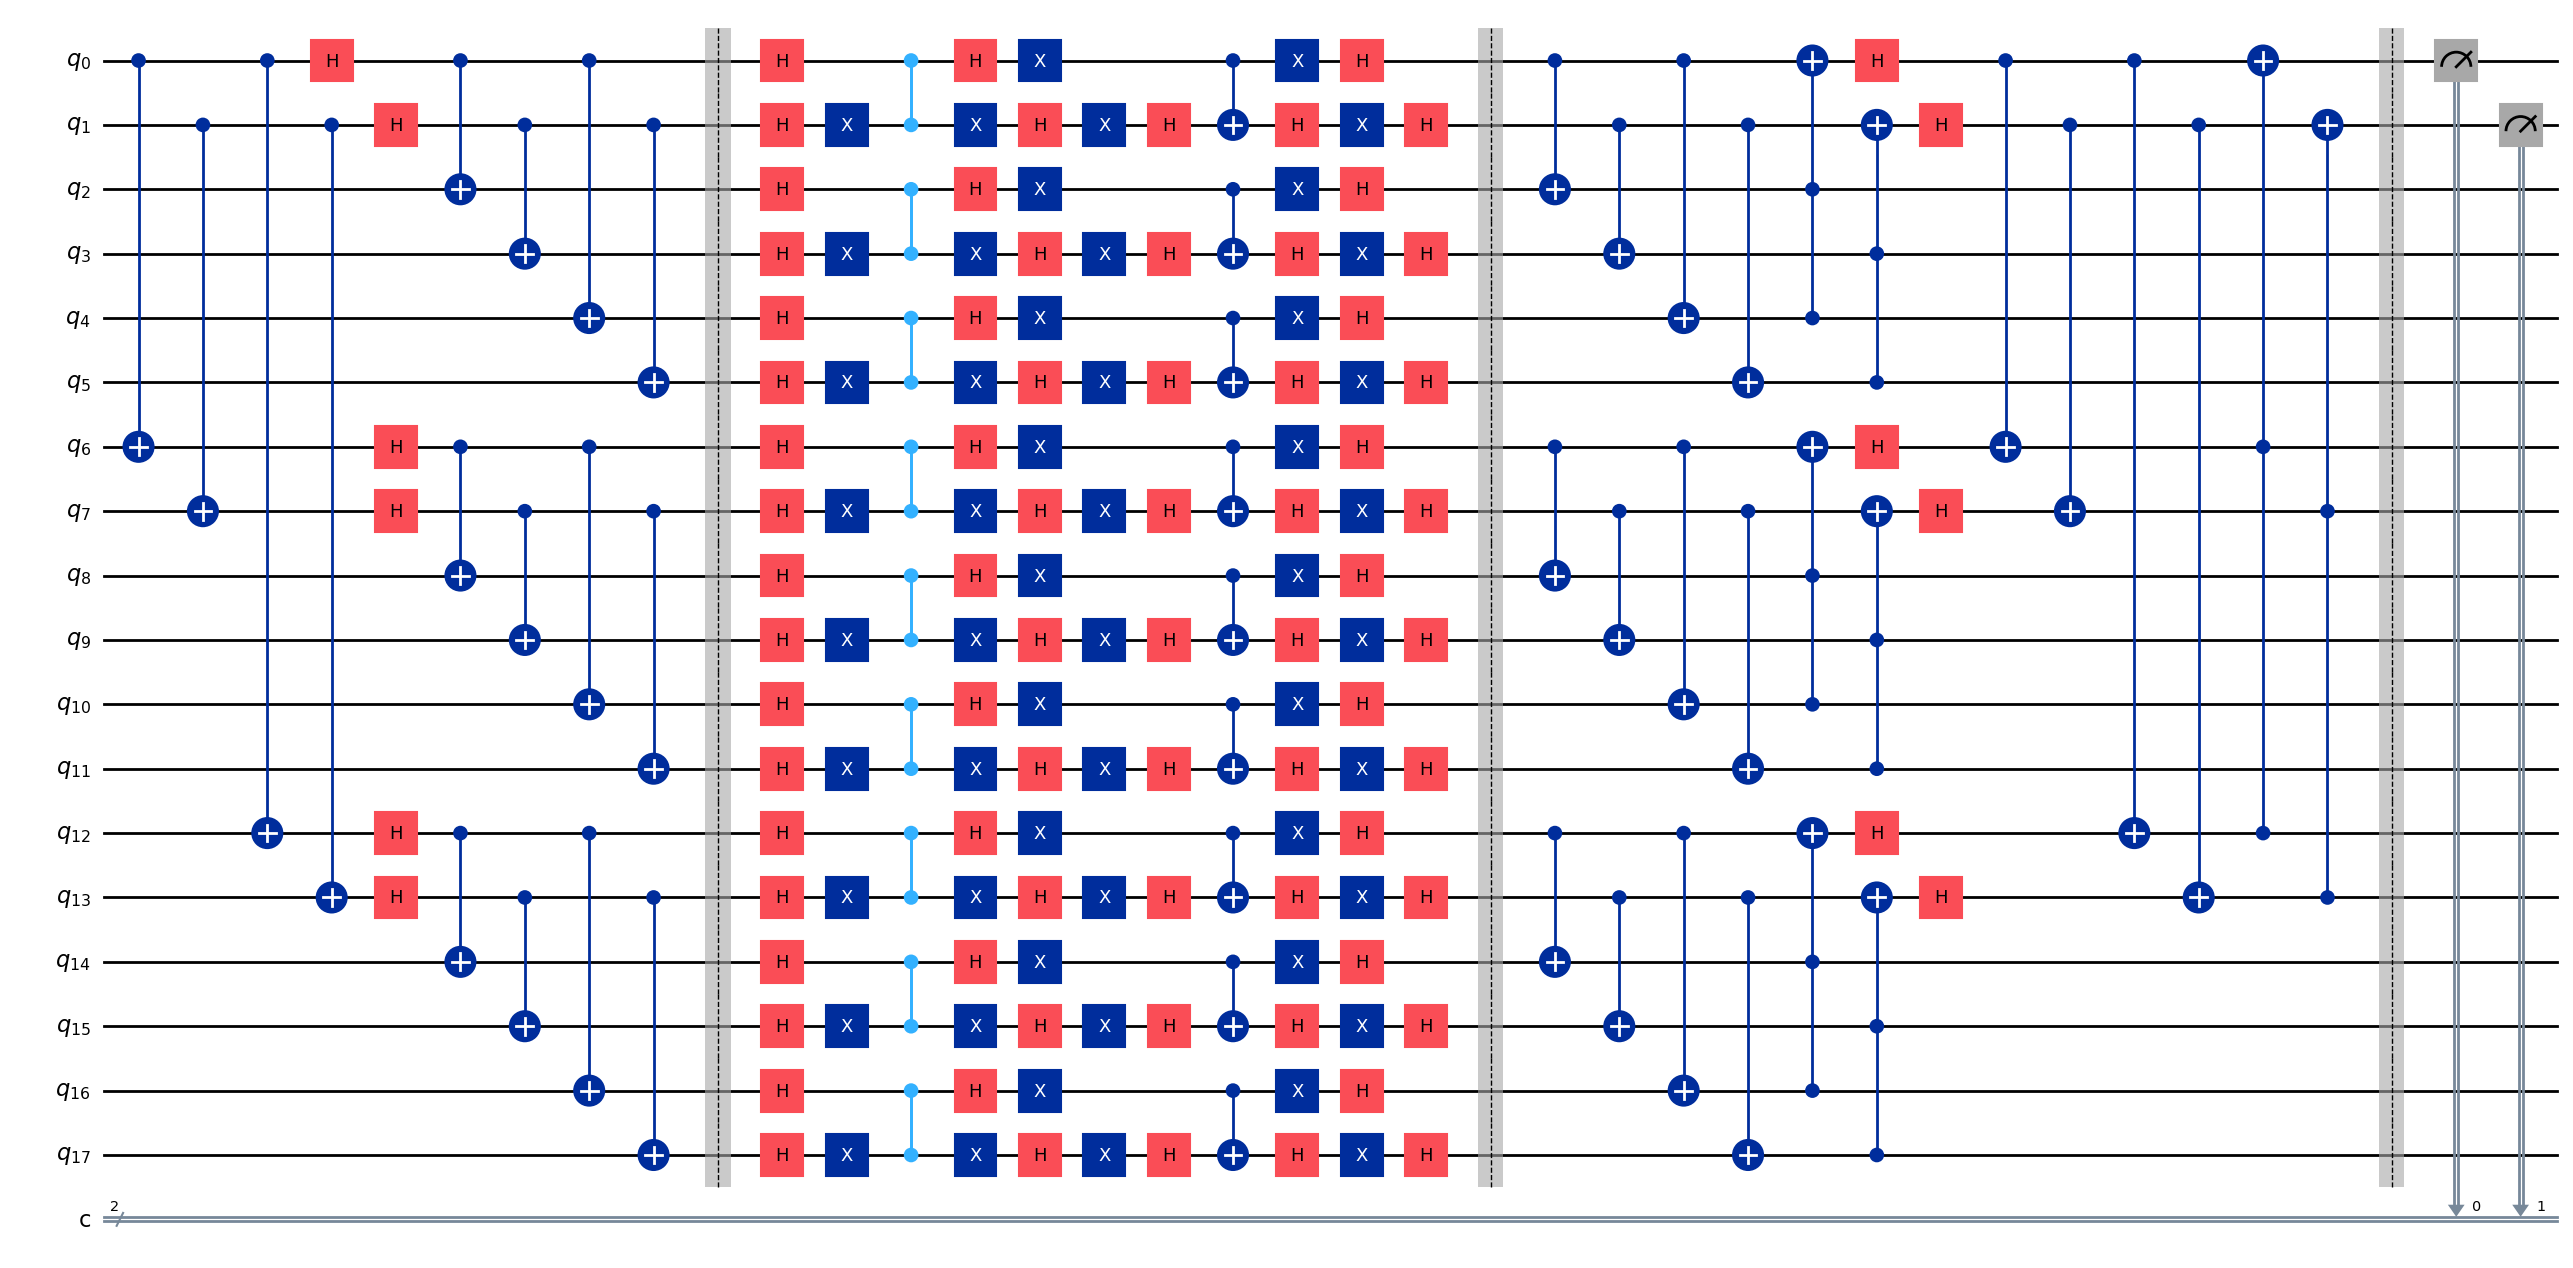

In [13]:
qc.draw('mpl', fold=False, idle_wires=False)

Run on IBM Quantum Machine

In [16]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1_024
job = sampler.run([circuit_qc])
results = job.result()

Plot Results

In [ ]:
dist = results[0].data.c.get_counts()
plot_distribution(dist)


Run Simulator

In [14]:
simulator = AerSimulator(noise_model=noise_model)
result = simulator.run(qc).result()

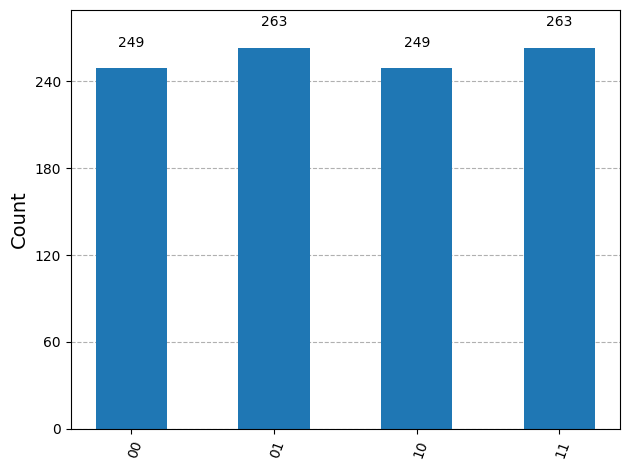

In [15]:
counts = result.get_counts(qc)
plot_histogram(counts)

In [16]:
simulator = AerSimulator()
result = simulator.run(qc).result()

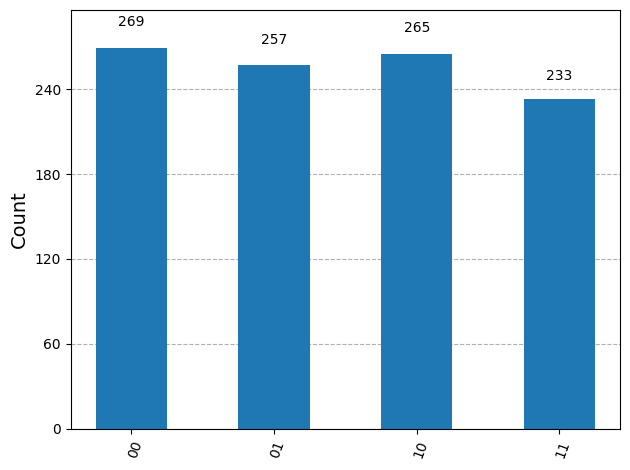

In [17]:
counts = result.get_counts(qc)
plot_histogram(counts)